# Pruebas y experimentos

En este notebook hay celdas con pruebas y experimentos realizados durante el desarrollo. No existe una evidencia para cada experimento, se utilizaba para una depuración y mejora dinámicas y las celdas se iban modificando para ejecutar cada prueba, quedando escrita la última que se realizara. También incluye la obtención de métricas y alguna gráfica.

## Pruebas búsqueda vectorial

### Generar clasificaciones de las alertas

In [64]:
# Crear dataset de descripciones y keywords (primer nodo)
import pandas as pd
import json

workflow = StateGraph(AgentState)
workflow.add_node('classification', classification_node)
workflow.set_entry_point('classification')
workflow.add_edge('classification', END)
app = workflow.compile()

df = pd.read_csv('data/unique_alerts.csv')
data = []

for i, row in df.iterrows():
    alert_data = json.loads(row['alert'])
    key_path = ['rule', 'mitre']  
    parent = alert_data
    for key in key_path[:-1]:
        parent = parent.get(key, {})
        if not isinstance(parent, dict):
            parent = {}
            break
    parent.pop(key_path[-1], None)
    labels = eval(row['real_ttps'])
    print(alert_data)
    print(labels)

    try:
        final_state = app.invoke({'original_alert': alert_data})
    except: 
        time.sleep(60)
        final_state = app.invoke({'original_alert': alert_data})

    data.append({
            'original_alert': alert_data,
            'description': final_state['classification'].mitre_description,
            'keywords': final_state['classification'].mitre_keywords,
            'alert_desc': alert_data['rule']['description'],
            'labels': labels
        }
    )

with open('data/unique_alerts_classification_v2.json', 'w', encoding='utf-8') as file:
    json.dump(data, file, indent=4, ensure_ascii=False)


{'timestamp': '2025-09-22T18:37:00.601+0000', 'rule': {'level': 6, 'description': 'Processes running for all users were queried with ps command.', 'id': '92604', 'firedtimes': 1, 'mail': False, 'groups': ['audit_detections']}, 'agent': {'id': '002', 'name': 'videoserver', 'ip': '172.17.100.121'}, 'manager': {'name': 'wazuh'}, 'id': '1758566220.11498102', 'full_log': 'type=SYSCALL msg=audit(1758566218.934:4968): arch=c000003e syscall=59 success=yes exit=0 a0=55de6e506188 a1=55de6e4f6c90 a2=55de6e5060f8 a3=1b6 items=3 ppid=3135 pid=3136 auid=4294967295 uid=33 gid=33 euid=33 suid=33 fsuid=33 egid=33 sgid=33 fsgid=33 tty=pts0 ses=4294967295 comm="ps" exe="/usr/bin/ps" subj==unconfined key="T1166_Seuid_and_Setgid"\x1dARCH=x86_64 SYSCALL=execve AUID="unset" UID="www-data" GID="www-data" EUID="www-data" SUID="www-data" FSUID="www-data" EGID="www-data" SGID="www-data" FSGID="www-data" type=EXECVE msg=audit(1758566218.934:4968): argc=2 a0="ps" a1="auxwww" type=PATH msg=audit(1758566218.934:4968

### Pruebas y experimentos

In [ ]:
import json
with open('data/unique_alerts_classification_v2.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

data[0]

{'original_alert': {'timestamp': '2025-09-22T18:37:00.601+0000',
  'rule': {'level': 6,
   'description': 'Processes running for all users were queried with ps command.',
   'id': '92604',
   'firedtimes': 1,
   'mail': False,
   'groups': ['audit_detections']},
  'agent': {'id': '002', 'name': 'videoserver', 'ip': '172.17.100.121'},
  'manager': {'name': 'wazuh'},
  'id': '1758566220.11498102',
  'full_log': 'type=SYSCALL msg=audit(1758566218.934:4968): arch=c000003e syscall=59 success=yes exit=0 a0=55de6e506188 a1=55de6e4f6c90 a2=55de6e5060f8 a3=1b6 items=3 ppid=3135 pid=3136 auid=4294967295 uid=33 gid=33 euid=33 suid=33 fsuid=33 egid=33 sgid=33 fsgid=33 tty=pts0 ses=4294967295 comm="ps" exe="/usr/bin/ps" subj==unconfined key="T1166_Seuid_and_Setgid"\x1dARCH=x86_64 SYSCALL=execve AUID="unset" UID="www-data" GID="www-data" EUID="www-data" SUID="www-data" FSUID="www-data" EGID="www-data" SGID="www-data" FSGID="www-data" type=EXECVE msg=audit(1758566218.934:4968): argc=2 a0="ps" a1="aux

In [ ]:
def predictions_check(global_metrics, results, labels):
    res = {'exact': 0, 'parent': 0, 'sub': 0, 'total_t': 0, 'total_a': 0}

    preds_set = set(results)
    # Precalculamos los padres de las predicciones que tienen subtécnica (ej: 'T1003.001' -> 'T1003')
    preds_parents_set = {pred.split('.')[0] for pred in results if '.' in pred}

    for label in labels:
        # 1. Prioridad Máxima: ¿Acierto Exacto?
        if label in preds_set:
            res['exact'] += 1
            res['total_t'] += 1
            continue  # Pasa al siguiente label, ignorando padre/hijo
            
        # Si no fue exacto, evaluamos si es padre o hijo
        has_subtechnique = '.' in label
        
        # 2. Segunda Prioridad: ¿Acierto Padre?
        # (El label real es sub-técnica, pero el modelo predijo la raíz)
        if has_subtechnique and (label.split('.')[0] in preds_set):
            res['parent'] += 1
            res['total_t'] += 1
            
        # 3. Tercera Prioridad: ¿Acierto Hijo?
        # (El label real es raíz, pero el modelo predijo una de sus sub-técnicas)
        elif not has_subtechnique and (label in preds_parents_set):
            res['sub'] += 1
            res['total_t'] += 1

    res['total_a'] = 1 if res['total_t'] > 0 else 0

    # Actualizamos métricas globales
    for metric, value in res.items():
        global_metrics[metric] += value
        
    return res

def query_full_text(vector_store, query, top_k):
    q_full_text = {
                "size": top_k,
                "query": {
                        "match": {
                            "text_to_search": {
                                "query": query,
                                # "boost": beta
                            }
                        }        
                }
    }

    response = vector_store.client.search(index=mitre_store.index_name, body=q_full_text)
    results = [hit['_source'] for hit in response['hits']['hits']]
    return results

def query_multi_match(vector_store, query, top_k):
    q_multi = {
            "size": top_k,
            "query": {
                    "multi_match": {
                        "query": query,
                        # Buscamos en el nombre (con peso x3), en el ID y en la descripción
                        "fields": ["name^3", "technique_id^2", "tactics", "description", "procedures", "detections"],
                        # "boost": 0.05 # Un peso muy bajito para que no rompa la escala del 0 al 1
                    }
                },
        }
    response = vector_store.client.search(index=mitre_store.index_name, body=q_multi)
    results = [hit['_source'] for hit in response['hits']['hits']]
    return results

def query_hybrid_simple(vector_store, query_vector, query_text, top_k):
    q = {
                "size": top_k,
                "knn": {
                    "field": "vector",
                    "query_vector": query_vector,
                    "k": top_k,
                    "num_candidates": 100,
                    "boost": 0.7
                },
                "query": {
                        "match": {
                            "text_to_search": {
                                "query": query_text,
                                "boost": 0.5
                            }
                        }        
                }
    }

    response = vector_store.client.search(index=mitre_store.index_name, body=q)
    results = [hit['_source'] for hit in response['hits']['hits']]
    return results



def rrf_fuse(ranked_lists: list[list[dict]], top_k: int = 10, k: int = 60) -> list[dict]:
    """
    Reciprocal Rank Fusion estándar.
 
    Cada lista es un ranking de documentos con 'technique_id'.
    Para cada técnica acumula: score += 1 / (k + posición_1_indexed)
    Devuelve los top_k documentos ordenados por score descendente.
 
    k=60 es el valor por defecto de la literatura.
    No requiere normalizar scores heterogéneos entre KNN y BM25.
    """
    scores: dict[str, float] = {}
    docs:   dict[str, dict]  = {}
 
    for ranked_list in ranked_lists:
        for rank, doc in enumerate(ranked_list):
            tid = doc.get('technique_id')
            if not tid:
                continue
            scores[tid] = scores.get(tid, 0.0) + 1.0 / (k + rank + 1)
            docs[tid] = doc   # conservamos el doc completo
 
    sorted_ids = sorted(scores, key=lambda x: -scores[x])[:top_k]
    return [docs[tid] for tid in sorted_ids], scores


In [ ]:
import copy

emb = SentenceTransformerEmbedder('BAAI/bge-small-en-v1.5')
mitre_store = ElasticSearchVectorStore(index_name='mitre_attack_v3_bge_small')
top_k = 10

methods = ['vector', 'BM25_full_text', 
           'BM25_multi',
           'hybrid',
           'all'
           ]

m_metrics = {
    'alert': {'exact': 0, 'parent': 0, 'sub': 0, 'total_t': 0, 'total_a': 0},
    'desc': {'exact': 0, 'parent': 0, 'sub': 0, 'total_t': 0, 'total_a': 0},
    'keywords': {'exact': 0, 'parent': 0, 'sub': 0, 'total_t': 0, 'total_a': 0},
    'combo': {'exact': 0, 'parent': 0, 'sub': 0, 'total_t': 0, 'total_a': 0}
}
total_t = 0
total_a = len(data)

global_m = {m: copy.deepcopy(m_metrics) for m in methods}
debug = []
for e in data:
    original_alert, description, keywords, alert_desc, labels = e.values()

    prefix = "Represent this sentence for searching relevant passages: " # Para bge (asimétrico)

    emb_desc = emb.embed_query(prefix + description)
    emb_keywords = emb.embed_query(prefix + keywords)
    emb_alert = emb.embed_query(prefix + alert_desc)

    # Método 1: Semántica pura (con cada texto)
    
    m1_desc = mitre_store.search(emb_desc, top_k=top_k)
    m1_keywords = mitre_store.search(emb_keywords, top_k=top_k)
    m1_alert = mitre_store.search(emb_alert, top_k=top_k)

    results_m1_desc = [r['technique_id'] for r in m1_desc]
    results_m1_keywords = [r['technique_id'] for r in m1_keywords]
    results_m1_alert = [r['technique_id'] for r in m1_alert]

    hits_m1_desc = predictions_check(global_m['vector']['desc'], results_m1_desc, labels)
    hits_m1_keywords = predictions_check(global_m['vector']['keywords'], results_m1_keywords, labels)
    hits_m1_alert = predictions_check(global_m['vector']['alert'], results_m1_alert, labels)
    hits_m1_combo = predictions_check(global_m['vector']['combo'], list(set(results_m1_desc+results_m1_keywords+results_m1_alert)), labels)

    # Método 2 (BM25 sobre full_text)

    m2_desc = query_full_text(mitre_store, description, top_k)
    m2_keywords = query_full_text(mitre_store, keywords, top_k)
    m2_alert = query_full_text(mitre_store, alert_desc, top_k)

    results_m2_desc = [r['technique_id'] for r in m2_desc]
    results_m2_keywords = [r['technique_id'] for r in m2_keywords]
    results_m2_alert = [r['technique_id'] for r in m2_alert]

    hits_m2_desc = predictions_check(global_m['BM25_full_text']['desc'], results_m2_desc, labels)
    hits_m2_keywords = predictions_check(global_m['BM25_full_text']['keywords'], results_m2_keywords, labels)
    hits_m2_alert = predictions_check(global_m['BM25_full_text']['alert'], results_m2_alert, labels)
    hits_m2_combo = predictions_check(global_m['BM25_full_text']['combo'], list(set(results_m2_desc+results_m2_keywords+results_m2_alert)), labels)  

    # Método 3 (BM25 con multi-query)

    m3_desc = query_multi_match(mitre_store, description, top_k)
    m3_keywords = query_multi_match(mitre_store, keywords, top_k)
    m3_alert = query_multi_match(mitre_store, alert_desc, top_k)

    results_m3_desc = [r['technique_id'] for r in m3_desc]
    results_m3_keywords = [r['technique_id'] for r in m3_keywords]
    results_m3_alert = [r['technique_id'] for r in m3_alert]

    hits_m3_desc = predictions_check(global_m['BM25_multi']['desc'], results_m3_desc, labels)
    hits_m3_keywords = predictions_check(global_m['BM25_multi']['keywords'], results_m3_keywords, labels)
    hits_m3_alert = predictions_check(global_m['BM25_multi']['alert'], results_m3_alert, labels)
    hits_m3_combo = predictions_check(global_m['BM25_multi']['combo'], list(set(results_m3_desc+results_m3_keywords+results_m3_alert)), labels)  

    # Método 4 (Híbrida)

    m4_desc = query_hybrid_simple(mitre_store, emb_desc, description, top_k)
    m4_keywords = query_hybrid_simple(mitre_store, emb_keywords, description, top_k)
    m4_alert = query_hybrid_simple(mitre_store, emb_alert, description, top_k)

    # m4_desc = hybrid_query_rrf_simple(mitre_store, emb_desc, keywords, top_k)
    # m4_keywords = hybrid_query_rrf_simple(mitre_store, emb_keywords, keywords, top_k)
    # m4_alert = hybrid_query_rrf_simple(mitre_store, emb_alert, keywords, top_k)

    results_m4_desc = [r['technique_id'] for r in m4_desc]
    results_m4_keywords = [r['technique_id'] for r in m4_keywords]
    results_m4_alert = [r['technique_id'] for r in m4_alert]

    hits_m4_desc = predictions_check(global_m['hybrid']['desc'], results_m4_desc, labels)
    hits_m4_keywords = predictions_check(global_m['hybrid']['keywords'], results_m4_keywords, labels)
    hits_m4_alert = predictions_check(global_m['hybrid']['alert'], results_m4_alert, labels)
    hits_m4_combo = predictions_check(global_m['hybrid']['combo'], list(set(results_m4_desc+results_m4_keywords+results_m4_alert)), labels)  

    sel = list(set(results_m1_keywords+results_m2_alert+results_m2_desc))
    all_results = list(set(results_m1_desc+results_m1_keywords+results_m2_desc+results_m2_keywords+results_m2_alert+results_m3_desc+results_m3_keywords+results_m3_alert))
    
    all_hits = predictions_check(global_m['all']['combo'], sel, labels)
    total_t += len(labels)


    debug.append({
            'original_alert': original_alert,
            'labels': labels,
            'alert_desc': alert_desc,
            'description': description,
            'keywords': keywords,
            'predictions': {
                'vector': {
                    'alert_results': results_m1_alert,
                    'alert_hits': hits_m1_alert,
                    'desc_results': results_m1_desc,
                    'desc_hits': hits_m1_desc,
                    'keywords_results': results_m1_keywords,
                    'keywords_hits': hits_m1_keywords
                },
                'BM25_full_text': {
                    'alert_results': results_m2_alert,
                    'alert_hits': hits_m2_alert,
                    'desc_results': results_m2_desc,
                    'desc_hits': hits_m2_desc,
                    'keywords_results': results_m2_keywords,
                    'keywords_hits': hits_m2_keywords
                },
                'BM25_multi': {
                    'alert_results': results_m3_alert,
                    'alert_hits': hits_m3_alert,
                    'desc_results': results_m3_desc,
                    'desc_hits': hits_m3_desc,
                    'keywords_results': results_m3_keywords,
                    'keywords_hits': hits_m3_keywords
                },
                'hybrid': {
                    'alert_results': results_m4_alert,
                    'alert_hits': hits_m4_alert,
                    'desc_results': results_m4_desc,
                    'desc_hits': hits_m4_desc,
                    'keywords_results': results_m4_keywords,
                    'keywords_hits': hits_m4_keywords
                }
            }
        })

with open('notes/query_debug_v2.json', 'w', encoding='utf-8') as file:
    json.dump(debug, file, indent=4, ensure_ascii=False)

print(global_m)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4249.50it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\omarinf\AppData\Local\Temp\ipykernel_2640\52421093.py:51: DeprecationWarning: The 'body' parameter is deprecated for the 'search' API and will be removed in a future version. Instead use API parameters directly. See https://github.com/elastic/elasticsearch-py/issues/1698 for more information
  response = vector_store.client.search(index=mitre_store.index_name, body=q_full_text)
C:\Users\omarinf\AppData\Local\Temp\ipykernel_2640\52421093.py:67: DeprecationWarning: The 'body' parameter is deprecated for the 'search' API and will be removed in a future version. Instead use API parameters directly. See https://github.

{'vector': {'alert': {'exact': 9, 'parent': 0, 'sub': 0, 'total_t': 9, 'total_a': 9}, 'desc': {'exact': 9, 'parent': 0, 'sub': 1, 'total_t': 10, 'total_a': 10}, 'keywords': {'exact': 17, 'parent': 0, 'sub': 0, 'total_t': 17, 'total_a': 16}, 'combo': {'exact': 17, 'parent': 0, 'sub': 0, 'total_t': 17, 'total_a': 16}}, 'BM25_full_text': {'alert': {'exact': 11, 'parent': 0, 'sub': 2, 'total_t': 13, 'total_a': 13}, 'desc': {'exact': 15, 'parent': 0, 'sub': 3, 'total_t': 18, 'total_a': 17}, 'keywords': {'exact': 14, 'parent': 0, 'sub': 1, 'total_t': 15, 'total_a': 14}, 'combo': {'exact': 19, 'parent': 0, 'sub': 1, 'total_t': 20, 'total_a': 19}}, 'BM25_multi': {'alert': {'exact': 11, 'parent': 0, 'sub': 2, 'total_t': 13, 'total_a': 13}, 'desc': {'exact': 11, 'parent': 0, 'sub': 1, 'total_t': 12, 'total_a': 12}, 'keywords': {'exact': 13, 'parent': 1, 'sub': 0, 'total_t': 14, 'total_a': 13}, 'combo': {'exact': 17, 'parent': 0, 'sub': 1, 'total_t': 18, 'total_a': 17}}, 'hybrid': {'alert': {'exa

In [2]:
emb = SentenceTransformerEmbedder('BAAI/bge-small-en-v1.5')
mitre_store = ElasticSearchVectorStore(index_name='mitre_attack_v3_bge_small')
top_k = 10

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7790.06it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
m_metrics = {'exact': 0, 'parent': 0, 'sub': 0, 'total_t': 0, 'total_a': 0}
total_t = 0
total_a = len(data)

for e in data:
    original_alert, description, keywords, alert_desc, labels = e.values()

    prefix = "Represent this sentence for searching relevant passages: " # Para bge (asimétrico)

    emb_desc = emb.embed_query(prefix + description)
    emb_keywords = emb.embed_query(prefix + keywords)
    emb_alert = emb.embed_query(prefix + alert_desc)

    emb_key_desc = emb.embed_query(prefix + keywords + f'. {description}')
    emb_desc_key = emb.embed_query(prefix + description + f'. Keywords: {keywords}')
    
    
    # search = query_hybrid_simple(mitre_store, emb_alert, alert_desc, top_k=top_k)
    # search2 = query_hybrid_simple(mitre_store, emb_keywords, description, top_k=top_k)
    search = mitre_store.search(emb_keywords, top_k=top_k)
    # search = search_mitre_ultimate(mitre_store,emb_keywords,emb_desc, alert_desc, keywords, top_k=top_k)
    # search2 = mitre_store.search(emb_keywords, top_k=top_k)
    search2 = query_full_text(mitre_store, description, top_k=top_k)
    # search4 = query_hybrid_simple(mitre_store, emb_desc, description, top_k=top_k)
    
    # combo_ponderado = interleave_results(search2,search,search3)
    # combo_results = [r['technique_id'] for r in combo_ponderado]

    results = [r['technique_id'] for r in search]
    results2 = [r['technique_id'] for r in search2]
    # results3 = [r['technique_id'] for r in search3]

    combo = list(set(results+results2))
    # fused = [search,search2,search3,search4]
    # fused_results, _ = rrf_fuse(fused, top_k=10)
    # fused_results = [r['technique_id'] for r in fused_results]
    hits = predictions_check(m_metrics, results, labels)


print(m_metrics)

C:\Users\omarinf\AppData\Local\Temp\ipykernel_17740\3799908321.py:51: DeprecationWarning: The 'body' parameter is deprecated for the 'search' API and will be removed in a future version. Instead use API parameters directly. See https://github.com/elastic/elasticsearch-py/issues/1698 for more information
  response = vector_store.client.search(index=mitre_store.index_name, body=q_full_text)


{'exact': 17, 'parent': 0, 'sub': 0, 'total_t': 17, 'total_a': 16}


## Experimentos de índices (TRAM)

### Limpieza de TRAM (etiquetas deprecadas)

Cargamos todas las técnicas, sin eliminar revocadas y deprecadas

In [4]:
from mitreattack.stix20 import MitreAttackData
import json

mitre_data = MitreAttackData('data/enterprise-attack.json')
techniques = mitre_data.get_techniques(remove_revoked_deprecated=False) 

deprecated = []
for t in techniques:
    if t.get("revoked") or t.get("x_mitre_deprecated"):
        deprecated.append(mitre_data.get_attack_id(t.id))

Abrimos el dataset de TRAM

In [5]:
with open('data/single_label.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

data[:2]

[{'text': 'This file extracts credentials from LSASS similar to Mimikatz.',
  'label': 'T1003.001',
  'doc_title': 'NotPetya Technical Analysis  A Triple Threat File Encryption MFT Encryption Credential Theft'},
 {'text': 'It calls OpenProcess on lsass.exe with access flag set to VM_READ, and looks for the modules wdigest.dll and lsasrv.dll loaded in the lsass.exe process.',
  'label': 'T1003.001',
  'doc_title': 'NotPetya Technical Analysis  A Triple Threat File Encryption MFT Encryption Credential Theft'}]

Comprobamos si contiene etiquetas deprecadas o revocadas

In [93]:
dep_count = 0
dep_ex = []


for e in data:
    _, label, _ = e.values()
    if label in deprecated:
        dep_count += 1
        dep_ex.append(label)

print(dep_count)
set(dep_ex)

176


{'T1562.001', 'T1574.002'}

Creamos un mapeo directo a la versión actualizada de las etiquetas y lo guardamos

In [92]:
mapping_dict = {
    'T1562.001': 'T1685',
    'T1574.002': 'T1574.001'
}

new_data = []

for e in data:
    t, label, _ = e.values()
    new_data.append({'text': t,
                        'label': mapping_dict.get(label, label)})
        
with open('data/tram_data.json', 'w', encoding='utf-8') as file:
    json.dump(new_data, file, indent=4, ensure_ascii=False)

### Experimentos con TRAM y distintos índices

In [164]:
with open('data/tram_data.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

data

[{'text': 'This file extracts credentials from LSASS similar to Mimikatz.',
  'label': 'T1003.001'},
 {'text': 'It calls OpenProcess on lsass.exe with access flag set to VM_READ, and looks for the modules wdigest.dll and lsasrv.dll loaded in the lsass.exe process.',
  'label': 'T1003.001'},
 {'text': 'It spreads to Microsoft Windows machines using several propagation methods, including the EternalBlue exploit for the CVE-2017-0144 vulnerability in the SMB service.',
  'label': 'T1210'},
 {'text': 'SMB exploitation via EternalBlue', 'label': 'T1210'},
 {'text': 'SMBv1 Exploitation via EternalBlue', 'label': 'T1210'},
 {'text': 'has the capability to exploit SMBv1 via the well known EternalBlue exploit.',
  'label': 'T1210'},
 {'text': 'SMB copy and remote execution', 'label': 'T1570'},
 {'text': 'This thread is then used to execute the SMB copy and remote execution',
  'label': 'T1570'},
 {'text': 'SMB copy and remote execution', 'label': 'T1570'},
 {'text': 'SMB Copy and Remote Executi

In [ ]:
from tqdm import tqdm

k_valores = [1,3,5,10,50,100]

aciertos = {k:0 for k in k_valores}
fallos = []

for e in tqdm(data, desc='Evaluando embeddings'):
    text,label = e.values()

    query = emb.embed_query(text)

    results_hybrid = query_hybrid_simple(mitre_store, query, text, top_k=100)

    results_100_hybrid = [results_hybrid[i]['technique_id'] for i in range(100)]


    if label in results_100_hybrid:
        top = results_100_hybrid.index(label)
        for k in k_valores:
            if top < k:
                aciertos[k] += 1

    if label not in results_100_hybrid[:10]:
        if label in results_100_hybrid:
            top = results_100_hybrid.index(label)
        else:
            top = '+100'

        fallos.append((text, label, top))
    
   
accuracy = {f'Top-{k}': (hits / len(data)) for k, hits in aciertos.items()}

Evaluando embeddings:   0%|          | 0/5089 [00:00<?, ?it/s]C:\Users\omarinf\AppData\Local\Temp\ipykernel_27688\13877414.py:91: DeprecationWarning: The 'body' parameter is deprecated for the 'search' API and will be removed in a future version. Instead use API parameters directly. See https://github.com/elastic/elasticsearch-py/issues/1698 for more information
  response = vector_store.client.search(index=mitre_store.index_name, body=q)
Evaluando embeddings: 100%|██████████| 5089/5089 [10:51<00:00,  7.82it/s]


Obtenemos una gráfica comparativa con los resultados de los experimentos más relevantes

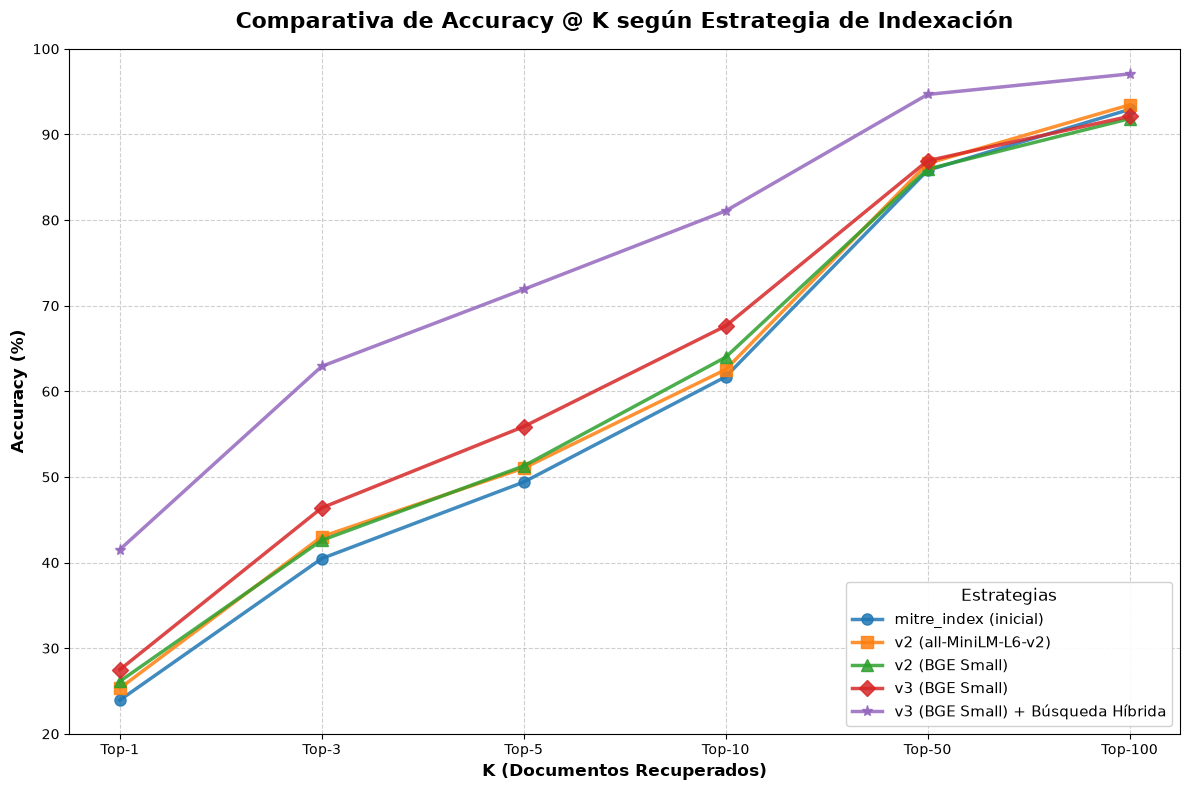

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Definimos los datos (anotados en search_evals)
data = {
    'mitre_index (inicial)': {
        'Top-1': 0.2393, 'Top-3': 0.4047, 'Top-5': 0.4940,
        'Top-10': 0.6170, 'Top-50': 0.8581, 'Top-100': 0.9292
    },
    'v2 (all-MiniLM-L6-v2)': {
        'Top-1': 0.2532, 'Top-3': 0.4303, 'Top-5': 0.5103,
        'Top-10': 0.6254, 'Top-50': 0.8661, 'Top-100': 0.9345
    },
    'v2 (BGE Small)': {
        'Top-1': 0.2613, 'Top-3': 0.4260, 'Top-5': 0.5128,
        'Top-10': 0.6398, 'Top-50': 0.8595, 'Top-100': 0.9184
    },
    'v3 (BGE Small)': {
        'Top-1': 0.2749, 'Top-3': 0.4639, 'Top-5': 0.5588,
        'Top-10': 0.6763, 'Top-50': 0.8693, 'Top-100': 0.9212
    },
    'v3 (BGE Small) + Búsqueda Híbrida': {
        'Top-1': 0.4152, 'Top-3': 0.6292, 'Top-5': 0.7191,
        'Top-10': 0.8107, 'Top-50': 0.9467, 'Top-100': 0.9707
    }
}


plt.figure(figsize=(12, 8))

# Categorías en el eje X 
categories = ['Top-1', 'Top-3', 'Top-5', 'Top-10', 'Top-50', 'Top-100']

# Marcadores para hacer las líneas fácilmente distinguibles 
markers = ['o', 's', '^', 'D', '*']

for (label, values), marker in zip(data.items(), markers):
    y_values = [values[cat] * 100 for cat in categories]

    plt.plot(categories, y_values, marker=marker, markersize=8, linewidth=2.5, 
             label=label, alpha=0.85)

plt.title('Comparativa de Accuracy @ K según Estrategia de Indexación', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('K (Documentos Recuperados)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')

# Limitar el eje Y entre 0 y 100 con divisiones de 10 en 10
plt.ylim(20, 100) 
plt.yticks(np.arange(20, 101, 10))

# Añadir una cuadrícula punteada para facilitar la lectura de los valores
plt.grid(True, linestyle='--', alpha=0.6, which='major')

# Leyenda abajo a la derecha, donde no suele molestar a la curva de Accuracy@K
plt.legend(title='Estrategias', title_fontsize='12', fontsize='11', 
           loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.show() 

## Comparar cambios entre evaluaciones

In [50]:
import pandas as pd

df = pd.read_csv('evaluations/alerts_results.csv')

In [51]:
def evaluar_prediccion(row):
    predicted = eval(row['predicted_ttps'])
    real = eval(row['real_ttps'])

    # Lógica de acierto que definiste
    if any(ttp in real for ttp in predicted):
        return 'acierto'
    
    real_parents = [r.split('.')[0] for r in real]
    predicted_parents = [p.split('.')[0] for p in predicted]
    
    if any(ttp in real_parents for ttp in predicted_parents):
        return 'acierto_parcial'
    
    return 'fallo'

# Aplicamos la evaluación
df['estado'] = df.apply(evaluar_prediccion, axis=1)

In [52]:
# Supongamos que tienes df_v1 (antes) y df_v2 (después)
df_v1 = df[df['evaluation_id'] == 'EVAL-3548AF']
df_v2 = df[df['evaluation_id'] == 'EVAL-46BA4E']
cols = ['alert_description','real_ttps', 'evaluation_id', 'predicted_ttps','estado']

# Nos aseguramos de tener solo las columnas necesarias
df_comparativa = df_v1[cols].merge(
    df_v2[cols], 
    on=['alert_description', 'real_ttps'], 
    suffixes=('_old', '_new')
)

# Identificamos los cambios
def detectar_cambio(row):
    if row['estado_old'] == row['estado_new']:
        return 'sin_cambios'
    return f"de_{row['estado_old']}_a_{row['estado_new']}"

df_comparativa['cambio'] = df_comparativa.apply(detectar_cambio, axis=1)

# Resultado: ver cuántas alertas ganaste o perdiste
print(df_comparativa['cambio'].value_counts())

cambio
sin_cambios                     18
de_fallo_a_acierto               1
de_acierto_parcial_a_acierto     1
Name: count, dtype: int64


In [53]:
# Tabla cruzada para ver el flujo de estados
transicion = pd.crosstab(df_comparativa['estado_old'], df_comparativa['estado_new'])
print(transicion)

estado_new       acierto  acierto_parcial  fallo
estado_old                                      
acierto               14                0      0
acierto_parcial        1                1      0
fallo                  1                0      3


In [54]:
def analizar_diferencia(row):
    preds_old = set(eval(row['predicted_ttps_old']))
    preds_new = set(eval(row['predicted_ttps_new']))
    
    agregados = list(preds_new - preds_old)
    quitados = list(preds_old - preds_new)
    
    return f"Añadió: {agregados} | Quitó: {quitados}"

df_cambios = df_comparativa[df_comparativa['estado_old'] != df_comparativa['estado_new']].copy()
df_cambios['detalle_cambio'] = df_cambios.apply(analizar_diferencia, axis=1)

In [55]:
df_cambios

,alert_description,real_ttps,evaluation_id_old,predicted_ttps_old,estado_old,evaluation_id_new,predicted_ttps_new,estado_new,cambio,detalle_cambio
11,Multiple common web attacks from same source ip.,"['T1055', 'T1083']",EVAL-3548AF,"['T1190', 'T1046', 'T1595.002', 'T1059.004']",fallo,EVAL-46BA4E,"['T1190', 'T1595.002', 'T1083', 'T1059.004']",acierto,de_fallo_a_acierto,Añadió: ['T1083'] | Quitó: ['T1046']
13,Multiple XSS (Cross Site Scripting) attempts f...,['T1059'],EVAL-3548AF,"['T1046', 'T1190', 'T1595.003', 'T1059.007']",acierto_parcial,EVAL-46BA4E,"['T1189', 'T1046', 'T1190', 'T1059', 'T1595.00...",acierto,de_acierto_parcial_a_acierto,"Añadió: ['T1189', 'T1059'] | Quitó: []"


In [141]:
# Ejemplo: Ver solo los que mejoraron
mejoras = df_cambios[
    (df_cambios['estado_old'] == 'fallo') & 
    (df_cambios['estado_new'] == 'acierto')
]

mejoras[['evaluation_id_new', 'detalle_cambio', 'predicted_ttps_old', 'predicted_ttps_new']]

,evaluation_id_new,detalle_cambio,predicted_ttps_old,predicted_ttps_new
10,EVAL-0CD507,"Añadió: ['T1595', 'T1083'] | Quitó: []",['T1595.003'],"['T1595.003', 'T1083', 'T1595']"


## Obtención de métricas finales

In [ ]:
import pandas as pd
import ast
import json

mitre_evaluations = {
    'gemini-top-5-no-context': 'EVAL-3CC2EE',
    'gemini-top-5-context': 'EVAL-86CB9E',
    'gemini-top-10-no-context': 'EVAL-3548AF',
    'gemini-top-10-context': 'EVAL-46BA4E',
    'gemma-top-5-no-context': 'EVAL-AA144A',
    'gemma-top-5-context': 'EVAL-932282',
    'gemma-top-10-no-context': 'EVAL-B068F6',
    'gemma-top-10-context': 'EVAL-04D59B',
}

cve_evaluations = {
    'gemini-top-5': 'EVAL-79E93D',
    'gemini-top-10': 'EVAL-A4AD8D',
    'gemma-top-5': 'EVAL-91315F',
    'gemma-top-10': 'EVAL-D1F60D',
}

# Invertir diccionarios para hacer el mapeo al final (Id -> Nombre Legible)
id_to_name_ttp = {v: k for k, v in mitre_evaluations.items()}
id_to_name_cve = {v: k for k, v in cve_evaluations.items()}

# Funciones auxiliares de lectura
def safe_parse_list(val):
    try:
        return ast.literal_eval(val) if pd.notnull(val) else []
    except: return []

def safe_parse_dict(val):
    try:
        val = val.replace("'", '"')
        return json.loads(val) if pd.notnull(val) else {}
    except: return {}

# Carga del dataset original
df_raw = pd.read_csv('evaluations/alerts_results.csv')

In [ ]:
# Filtrar ANTES de procesar
df_ttp = df_raw[df_raw['evaluation_id'].isin(id_to_name_ttp.keys())].copy()

# Parsear solo lo necesario
df_ttp['pred_ttps_list'] = df_ttp['predicted_ttps'].apply(safe_parse_list)
df_ttp['real_ttps_list'] = df_ttp['real_ttps'].apply(safe_parse_list)
df_ttp['token_dict'] = df_ttp['token_usage'].apply(safe_parse_dict)
df_ttp['total_tokens'] = df_ttp['token_dict'].apply(lambda x: x.get('total_tokens', 0))

def evaluate_ttps(row):
    pred_ttps = row['pred_ttps_list']
    real_ttps = row['real_ttps_list']
    
    if not real_ttps: return pd.Series([None, None, None, None, None, None, 0.0, 0.0, 0, 0])
    if not pred_ttps: return pd.Series([0, 0, 0, 0, 0.0, 0.0, 0.0, 0.0, 0, len(real_ttps)])

    has_exact, has_sub, has_parent = False, False, False
    pred_families = set(p.split('.')[0] for p in pred_ttps)
    real_families = set(r.split('.')[0] for r in real_ttps)

    valid_preds_score = 0.0
    for p in pred_ttps:
        p_family = p.split('.')[0]
        if p_family in real_families:
            valid_preds_score += 1.0
            
            if p in real_ttps:
                has_exact = True
            else:
                matching_reals = [r for r in real_ttps if r.split('.')[0] == p_family]
                if p_family in matching_reals:
                    has_sub = True
                else:
                    has_parent = True

    macro_precision = valid_preds_score / len(pred_ttps)
    recall_score = sum(1.0 for r in real_ttps if r.split('.')[0] in pred_families)
    macro_recall = recall_score / len(real_ttps)
    
    hit_exact = 1 if has_exact else 0
    hit_sub = 1 if (not has_exact and has_sub) else 0
    hit_parent = 1 if (not has_exact and not has_sub and has_parent) else 0
    hit_total = 1 if (hit_exact or hit_sub or hit_parent) else 0

    return pd.Series([
        hit_total, hit_exact, hit_parent, hit_sub, 
        macro_recall, macro_precision, 
        valid_preds_score, recall_score, len(pred_ttps), len(real_ttps)
    ])

df_ttp[['hr_total', 'hr_exact', 'hr_parent', 'hr_sub', 
        'macro_recall', 'macro_precision', 
        'ttp_valid_score', 'ttp_recall_score', 'ttp_pred_count', 'ttp_real_count']] = df_ttp.apply(evaluate_ttps, axis=1)

summary_ttp = df_ttp.groupby('evaluation_id').agg(
    total_alerts=('alert_id', 'count'),

    # Hit Rate Desglosado por Alerta (Calculamos la media de los 0s y 1s para obtener el %)
    hr_total=('hr_total', 'mean'),
    hr_exact=('hr_exact', 'mean'),
    hr_parent=('hr_parent', 'mean'),
    hr_sub=('hr_sub', 'mean'),

    # Macro-métricas
    macro_recall=('macro_recall', 'mean'),
    macro_precision=('macro_precision', 'mean'),

    # Sumas para calcular las Micro-métricas globales
    sum_valid_score=('ttp_valid_score', 'sum'),
    sum_recall_score=('ttp_recall_score', 'sum'),
    sum_pred_count=('ttp_pred_count', 'sum'),
    sum_real_count=('ttp_real_count', 'sum'),

    # Rendimiento
    avg_time_s=('execution_time', 'mean'),
    avg_tokens=('total_tokens', 'mean')
).reset_index()

summary_ttp['micro_recall'] = summary_ttp['sum_recall_score'] / summary_ttp['sum_real_count']
summary_ttp['micro_precision'] = summary_ttp['sum_valid_score'] / summary_ttp['sum_pred_count']

cols_to_percent = ['hr_total', 'hr_exact', 'hr_parent', 'hr_sub', 'macro_recall', 'micro_recall', 'macro_precision', 'micro_precision']
for col in cols_to_percent: summary_ttp[col] = (summary_ttp[col] * 100).round(2)

summary_ttp = summary_ttp.drop(columns=['sum_valid_score', 'sum_recall_score', 'sum_pred_count', 'sum_real_count'])
summary_ttp['configuracion'] = summary_ttp['evaluation_id'].map(id_to_name_ttp)
summary_ttp['Modelo'] = summary_ttp['configuracion'].apply(lambda x: 'Gemini' if 'gemini' in x else 'Gemma')
summary_ttp['Top-k'] = summary_ttp['configuracion'].apply(lambda x: 10 if '10' in x else 5)
summary_ttp['Contexto'] = summary_ttp['configuracion'].apply(lambda x: False if 'no-context' in x else True)

metric_cols_ttp = [c for c in summary_ttp.columns if c not in ['evaluation_id', 'configuracion', 'Modelo', 'Top-k', 'Contexto']]
final_ttp = summary_ttp[['Modelo', 'Top-k', 'Contexto'] + metric_cols_ttp].sort_values(by=['Top-k', 'Modelo', 'Contexto'], ascending=[True, True, True]).reset_index(drop=True)

# Guardar Resultados TTP
final_ttp.to_csv('evaluations/mitre_evaluation.csv', index=False)
print("TTPs calculados y guardados exitosamente.\n")
print(final_ttp.to_string(index=False))

TTPs calculados y guardados exitosamente.

Modelo  Top-k  Contexto  total_alerts  hr_total  hr_exact  hr_parent  hr_sub  macro_recall  macro_precision  avg_time_s  avg_tokens  micro_recall  micro_precision
Gemini      5     False            20      70.0      65.0        0.0     5.0         64.17            46.25     10.0815     8879.10         58.33            41.46
Gemini      5      True            20      75.0      70.0        0.0     5.0         69.17            45.42     10.1880    10110.90         62.50            40.00
 Gemma      5     False            20      60.0      55.0        0.0     5.0         56.67            37.25     92.6590     9234.95         54.17            34.88
 Gemma      5      True            20      60.0      50.0        0.0    10.0         56.67            31.83     97.2515    10605.70         54.17            30.00
Gemini     10     False            20      80.0      70.0        0.0    10.0         74.17            42.08     10.6640    11434.60         66

In [ ]:
df_cve = df_raw[df_raw['evaluation_id'].isin(id_to_name_cve.keys())].copy()

df_cve['pred_cves_list'] = df_cve['predicted_cves'].apply(safe_parse_list)
df_cve['real_cves_list'] = df_cve['real_cves'].apply(safe_parse_list)
df_cve['token_dict'] = df_cve['token_usage'].apply(safe_parse_dict)
df_cve['total_tokens'] = df_cve['token_dict'].apply(lambda x: x.get('total_tokens', 0))

def evaluate_cves(row):
    pred_cves = row['pred_cves_list']
    real_cves = row['real_cves_list']
    
    if not real_cves: return pd.Series([None, None, None, 0.0, 0.0, 0, 0])
    if not pred_cves: return pd.Series([0, 0.0, 0.0, 0.0, 0.0, 0, len(real_cves)])

    pred_set, real_set = set(pred_cves), set(real_cves)
    exact_hits_count = len(pred_set.intersection(real_set))

    macro_precision = exact_hits_count / len(pred_cves)
    macro_recall = exact_hits_count / len(real_cves)
    hit_total = 1 if exact_hits_count > 0 else 0

    return pd.Series([
        hit_total, macro_recall, macro_precision, 
        exact_hits_count, exact_hits_count, len(pred_cves), len(real_cves)
    ])

df_cve[['cve_hr_total', 'macro_recall', 'macro_precision', 
        'cve_valid_score', 'cve_recall_score', 'cve_pred_count', 'cve_real_count']] = df_cve.apply(evaluate_cves, axis=1)

summary_cve = df_cve.groupby('evaluation_id').agg(
    total_alerts=('alert_id', 'count'),
    
    # Hit Rate general (Al no haber jerarquía, el Total es igual al Exacto)
    cve_hr_total=('cve_hr_total', 'mean'),

    # Macro-métricas
    macro_recall=('macro_recall', 'mean'),
    macro_precision=('macro_precision', 'mean'),

    # Sumas para calcular las Micro-métricas globales
    sum_valid_score=('cve_valid_score', 'sum'),
    sum_recall_score=('cve_recall_score', 'sum'),
    sum_pred_count=('cve_pred_count', 'sum'),
    sum_real_count=('cve_real_count', 'sum'),

    # Rendimiento
    avg_time_s=('execution_time', 'mean'),
    avg_tokens=('total_tokens', 'mean')
).reset_index()

summary_cve['micro_recall'] = summary_cve['sum_recall_score'] / summary_cve['sum_real_count']
summary_cve['micro_precision'] = summary_cve['sum_valid_score'] / summary_cve['sum_pred_count']

cols_to_percent_cve = ['cve_hr_total', 'macro_recall', 'micro_recall', 'macro_precision', 'micro_precision']
for col in cols_to_percent_cve: summary_cve[col] = (summary_cve[col] * 100).round(2)

summary_cve = summary_cve.drop(columns=['sum_valid_score', 'sum_recall_score', 'sum_pred_count', 'sum_real_count'])
summary_cve['configuracion'] = summary_cve['evaluation_id'].map(id_to_name_cve)
summary_cve['Modelo'] = summary_cve['configuracion'].apply(lambda x: 'Gemini' if 'gemini' in x else 'Gemma')
summary_cve['Top-k'] = summary_cve['configuracion'].apply(lambda x: 10 if '10' in x else 5)
summary_cve['Contexto'] = summary_cve['configuracion'].apply(lambda x: False )

metric_cols_cve = [c for c in summary_cve.columns if c not in ['evaluation_id', 'configuracion', 'Modelo', 'Top-k', 'Contexto']]
final_cve = summary_cve[['Modelo', 'Top-k', 'Contexto'] + metric_cols_cve].sort_values(by=['Top-k', 'Modelo', 'Contexto'], ascending=[True, False, False]).reset_index(drop=True)

# Guardar Resultados CVE
final_cve.to_csv('evaluations/cve_evaluation.csv', index=False)
print("CVEs calculados y guardados exitosamente.")
print(final_cve.to_string(index=False))

CVEs calculados y guardados exitosamente.
Modelo  Top-k  Contexto  total_alerts  cve_hr_total  macro_recall  macro_precision  avg_time_s   avg_tokens  micro_recall  micro_precision
 Gemma      5     False            15         33.33         33.33            17.78  109.926667  9554.866667         33.33            22.73
Gemini      5     False            15         73.33         73.33            58.89   10.894000  8429.666667         73.33            64.71
 Gemma     10     False            15         20.00         20.00            13.33  129.438667 12063.733333         20.00            13.04
Gemini     10     False             0         73.33         73.33            62.22   18.957333 16594.333333         73.33            68.75
